# Parquet文件可视化工具

这个notebook用于可视化parquet文件的内容，特别适用于包含分子数据和口袋向量的数据集。


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# 读取parquet文件
file_path = "finetune_data/molgenbench_dataset/dataset_with_all_cond.parquet"

try:
    df = pd.read_parquet(file_path)
    print(f"成功读取文件: {file_path}")
    print(f"数据形状: {df.shape}")
    print(f"列名: {list(df.columns)}")
except FileNotFoundError:
    print(f"文件不存在: {file_path}")
    print("请检查文件路径是否正确")
    df = None


成功读取文件: finetune_data/molgenbench_dataset/dataset_with_all_cond.parquet
数据形状: (120, 9)
列名: ['id', 'split', 'protein_path', 'ligand_path', 'standardize_smi', 'pocket_vec', 'evo_vec', 'ifp', 'ligand_vec']


In [3]:
print(df['ligand_path'][0])

/home/yang2531/Documents/Project/StructureSAFE_benchmarking/MolGenBench/MolGenBench_Version1/O14757/O14757_lig.sdf


In [4]:
if df is not None:
    # 显示基本信息
    print("=== 数据集基本信息 ===")
    print(f"行数: {len(df)}")
    print(f"列数: {len(df.columns)}")
    print(f"内存使用: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("\n=== 数据类型 ===")
    print(df.dtypes)
    print("\n=== 前5行数据 ===")
    display(df.head())


=== 数据集基本信息 ===
行数: 120
列数: 9
内存使用: 0.12 MB

=== 数据类型 ===
id                 object
split              object
protein_path       object
ligand_path        object
standardize_smi    object
pocket_vec         object
evo_vec            object
ifp                object
ligand_vec         object
dtype: object

=== 前5行数据 ===


,id,split,protein_path,ligand_path,standardize_smi,pocket_vec,evo_vec,ifp,ligand_vec
0,bench_0,validation,/home/yang2531/Documents/Project/StructureSAFE...,/home/yang2531/Documents/Project/StructureSAFE...,NC(=O)Nc1cc(-c2ccc(F)c(F)c2)sc1C(=O)N[C@H]1CCC...,"[-1.44672945865475, -0.341295271746772, -0.962...","[-0.025152348, -0.078557715, -0.024536932, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[9.409917, 5.450827, -4.2526097, -9.514335, 5...."
1,bench_1,validation,/home/yang2531/Documents/Project/StructureSAFE...,/home/yang2531/Documents/Project/StructureSAFE...,CC(C(=O)n1cc2[nH][nH]c(=NC(O)c3ccc(N4CCN(C)CC4...,"[0.3310485921987899, -0.6078335922252247, -0.4...","[0.025226833, 0.021548927, -0.017675921, -0.09...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[13.068344, 8.634904, -13.837887, -14.876869, ..."
2,bench_2,validation,/home/yang2531/Documents/Project/StructureSAFE...,/home/yang2531/Documents/Project/StructureSAFE...,CC(C)(C)c1cc(=O)[nH]c(SCC(=O)c2ccc(S(N)(=O)=O)...,"[-0.10783706337679844, 0.10693562213792092, 0....","[0.040609512, -0.14077422, -0.015980601, 0.134...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[11.165522, 4.920516, -11.852919, -14.590656, ..."
3,bench_3,validation,/home/yang2531/Documents/Project/StructureSAFE...,/home/yang2531/Documents/Project/StructureSAFE...,C[C@@H]1CCN(C(=O)CC#N)C[C@@H]1N(C)c1ncnc2[nH]c...,"[0.4631464556751528, -1.0567754215113934, 0.74...","[-0.008588048, -0.00872449, -0.075974375, -0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[10.193136, 4.025799, -3.429223, -8.490389, 4...."
4,bench_4,validation,/home/yang2531/Documents/Project/StructureSAFE...,/home/yang2531/Documents/Project/StructureSAFE...,CCOc1cc(-c2c(C)noc2C)cc([C@H](C)O)c1,"[1.8294970007735014, 1.6018933024505948, -0.70...","[-0.023282787, -0.0719609, -0.14621402, 0.0176...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8.932283, 4.954155, -1.9557967, -5.980256, 4...."


In [5]:
df['protein_path'][0]

'/home/yang2531/Documents/Project/StructureSAFE_benchmarking/MolGenBench/MolGenBench_Version1/O14757/O14757_pocket10.pdb'

In [6]:
df['ligand_path'][0]

'/home/yang2531/Documents/Project/StructureSAFE_benchmarking/MolGenBench/MolGenBench_Version1/O14757/O14757_lig.sdf'

In [5]:
if df is not None:
    # 检查缺失值
    print("=== 缺失值统计 ===")
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    missing_df = pd.DataFrame({
        '缺失数量': missing_data,
        '缺失百分比': missing_percent
    })
    missing_df = missing_df[missing_df['缺失数量'] > 0].sort_values('缺失数量', ascending=False)
    
    if len(missing_df) > 0:
        display(missing_df)
    else:
        print("没有缺失值")
    
    # 检查重复行
    duplicate_count = df.duplicated().sum()
    print(f"\n重复行数量: {duplicate_count}")


=== 缺失值统计 ===
没有缺失值


TypeError: unhashable type: 'numpy.ndarray'

In [6]:
if df is not None:
    # 数值列统计
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print(f"数值列数量: {len(numeric_cols)}")
    
    if len(numeric_cols) > 0:
        print("\n=== 数值列统计信息 ===")
        display(df[numeric_cols].describe())
    
    # 分类列统计
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    print(f"\n分类列数量: {len(categorical_cols)}")
    
    if len(categorical_cols) > 0:
        print("\n=== 分类列唯一值统计 ===")
        for col in categorical_cols:
            unique_count = df[col].nunique()
            print(f"{col}: {unique_count} 个唯一值")
            if unique_count <= 20:  # 只显示唯一值较少的列
                print(f"  值: {df[col].unique()}")


数值列数量: 0

分类列数量: 9

=== 分类列唯一值统计 ===
id: 120 个唯一值
split: 1 个唯一值
  值: ['validation']
protein_path: 120 个唯一值
ligand_path: 120 个唯一值
standardize_smi: 120 个唯一值


TypeError: unhashable type: 'numpy.ndarray'

In [ ]:
if df is not None and len(numeric_cols) > 0:
    # 数值列分布可视化
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        if i < len(axes):
            axes[i].hist(df[col].dropna(), bins=50, alpha=0.7, edgecolor='black')
            axes[i].set_title(f'{col} 分布')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('频次')
    
    # 隐藏多余的子图
    for i in range(len(numeric_cols), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()


In [ ]:
if df is not None and len(numeric_cols) > 1:
    # 相关性热力图
    plt.figure(figsize=(12, 10))
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.2f')
    plt.title('数值列相关性热力图')
    plt.tight_layout()
    plt.show()

In [9]:
if df is not None:
    # 检查是否有口袋向量相关的列
    pocket_cols = [col for col in df.columns if 'pocket' in col.lower() or 'vec' in col.lower() or 'ifp' in col.lower()]
    print(f"口袋/向量相关列: {pocket_cols}")
    
    if pocket_cols:
        for col in pocket_cols:
            print(f"\n=== {col} 信息 ===")
            print(f"数据类型: {df[col].dtype}")
            print(f"非空值数量: {df[col].notna().sum()}")
            
            # 如果是列表或数组类型
            if df[col].dtype == 'object':
                sample_value = df[col].dropna().iloc[0] if df[col].notna().any() else None
                if sample_value is not None:
                    if isinstance(sample_value, (list, np.ndarray)):
                        print(f"向量维度: {len(sample_value)}")
                        print(f"向量类型: {type(sample_value)}")
                        print(f"前5个值: {sample_value[:5] if len(sample_value) > 5 else sample_value}")
                    else:
                        print(f"示例值: {sample_value}")


口袋/向量相关列: ['pocket_vec', 'evo_vec', 'ifp', 'ligand_vec']

=== pocket_vec 信息 ===
数据类型: object
非空值数量: 120
向量维度: 512
向量类型: <class 'numpy.ndarray'>
前5个值: [-1.44672946 -0.34129527 -0.96234769 -0.50958095  0.27473173]

=== evo_vec 信息 ===
数据类型: object
非空值数量: 120
向量维度: 1280
向量类型: <class 'numpy.ndarray'>
前5个值: [-0.02515235 -0.07855771 -0.02453693  0.04043692 -0.07127918]

=== ifp 信息 ===
数据类型: object
非空值数量: 120
向量维度: 16384
向量类型: <class 'numpy.ndarray'>
前5个值: [0. 0. 0. 0. 0.]

=== ligand_vec 信息 ===
数据类型: object
非空值数量: 120
向量维度: 1536
向量类型: <class 'numpy.ndarray'>
前5个值: [ 9.409917   5.450827  -4.2526097 -9.514335   5.0906315]


pocket_vec 向量维度: {512}


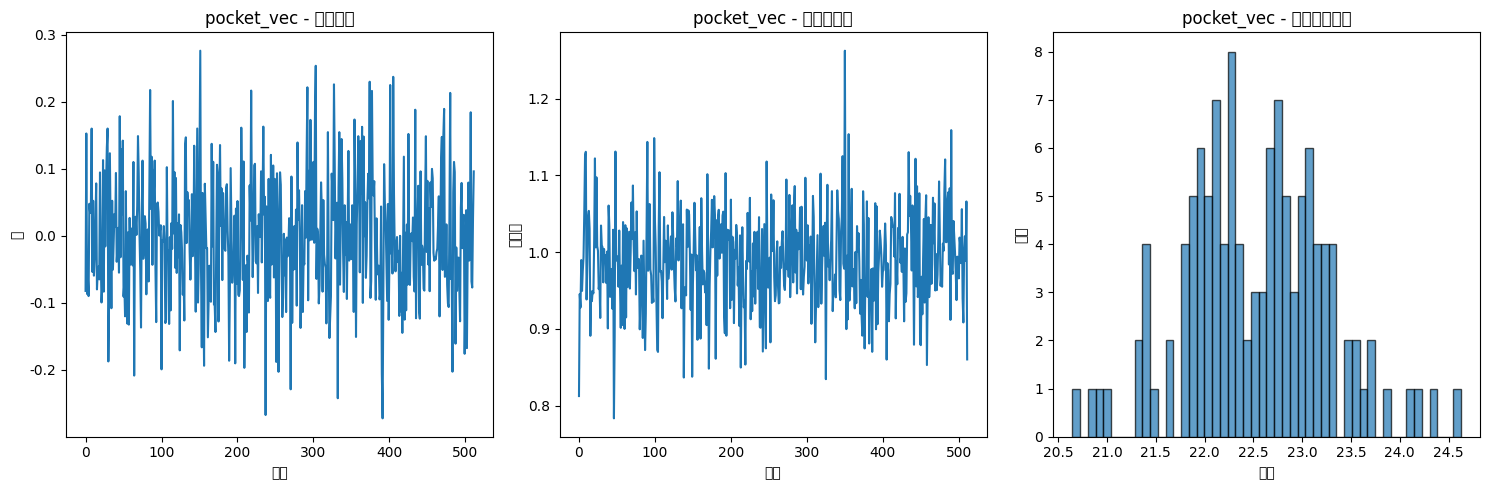

向量统计:
  均值范围: [-0.2725, 0.2763]
  标准差范围: [0.7834, 1.2623]
  范数范围: [20.6450, 24.6228]
evo_vec 向量维度: {1280}


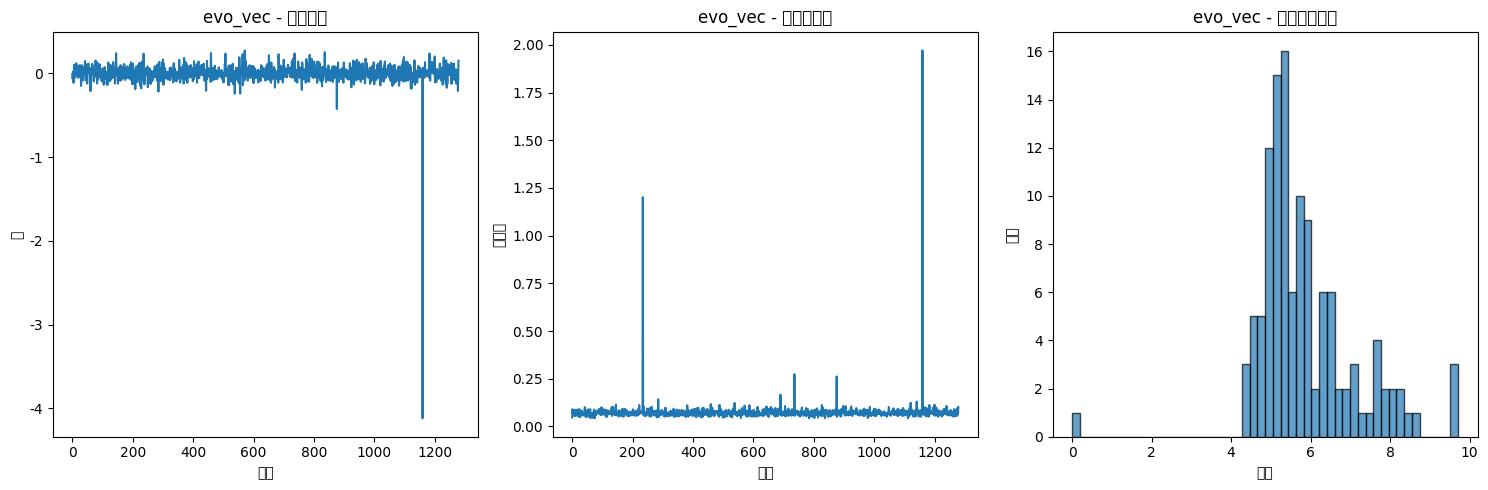

向量统计:
  均值范围: [-4.1177, 0.2711]
  标准差范围: [0.0422, 1.9711]
  范数范围: [0.0000, 9.7119]
ifp 向量维度: {16384}


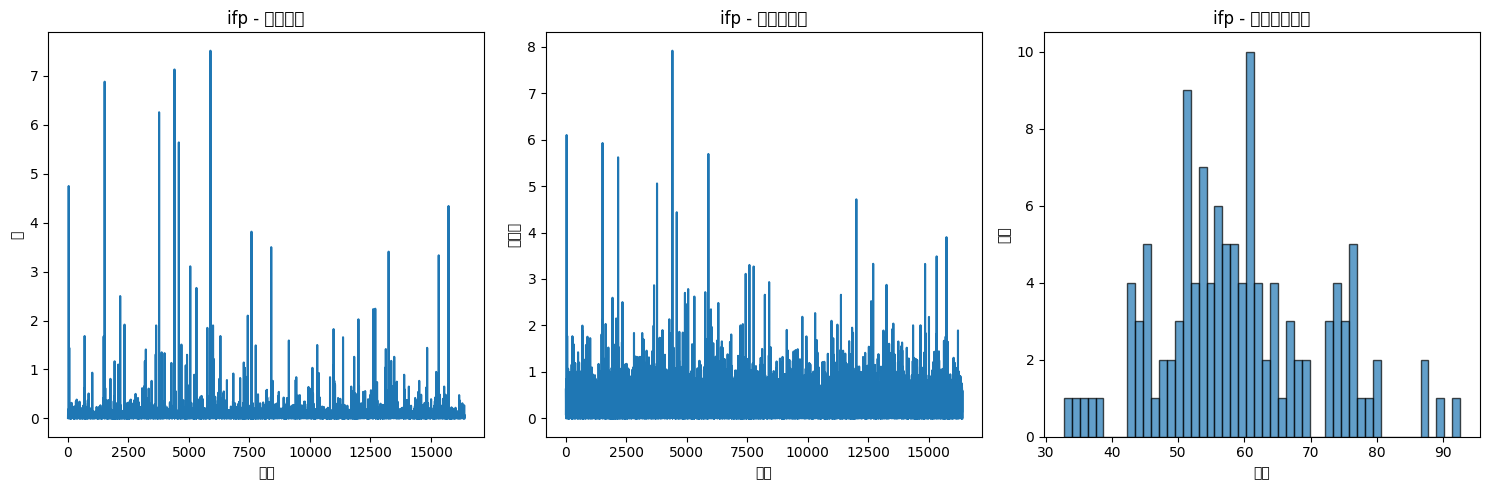

向量统计:
  均值范围: [0.0000, 7.5167]
  标准差范围: [0.0000, 7.9130]
  范数范围: [32.7414, 92.5527]
ligand_vec 向量维度: {1536}


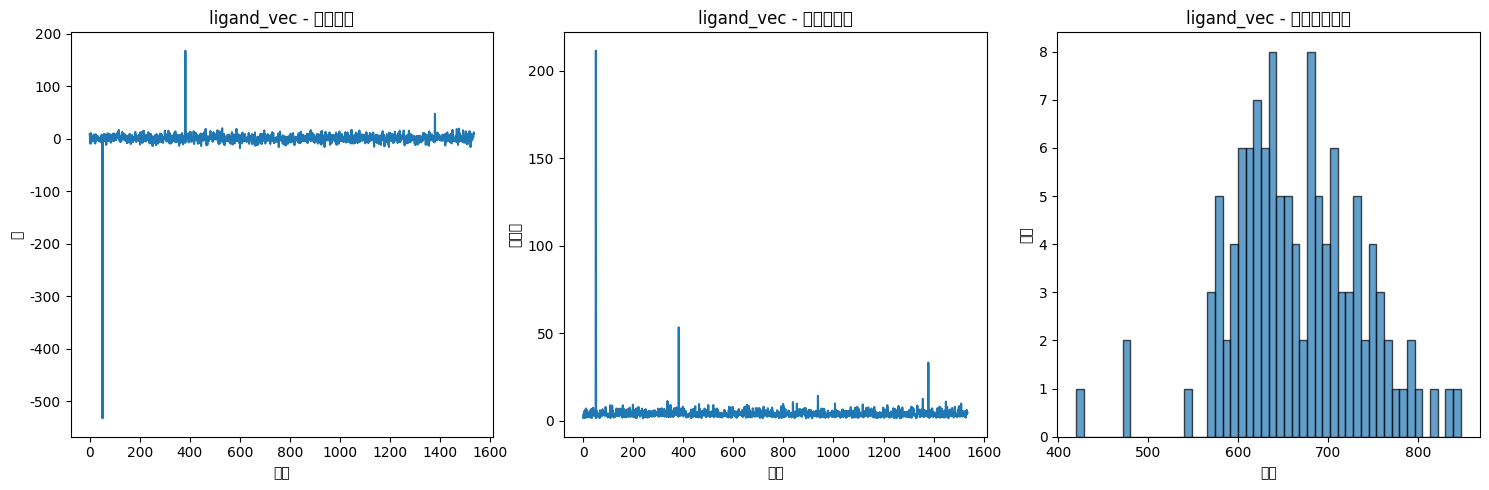

向量统计:
  均值范围: [-532.7109, 168.0525]
  标准差范围: [1.3261, 211.4154]
  范数范围: [420.2959, 847.5298]


In [10]:
if df is not None and pocket_cols:
    # 可视化口袋向量（如果是数值向量）
    for col in pocket_cols:
        if df[col].dtype == 'object':
            # 尝试提取向量数据
            try:
                # 假设向量存储为列表
                vectors = df[col].dropna().apply(lambda x: np.array(x) if isinstance(x, (list, np.ndarray)) else None)
                vectors = vectors.dropna()
                
                if len(vectors) > 0:
                    # 检查向量维度
                    vector_dims = [len(v) for v in vectors]
                    unique_dims = set(vector_dims)
                    print(f"{col} 向量维度: {unique_dims}")
                    
                    if len(unique_dims) == 1:  # 所有向量维度相同
                        dim = list(unique_dims)[0]
                        # 转换为矩阵
                        vector_matrix = np.array([v for v in vectors])
                        
                        # 可视化向量的统计信息
                        plt.figure(figsize=(15, 5))
                        
                        # 向量均值
                        plt.subplot(1, 3, 1)
                        plt.plot(vector_matrix.mean(axis=0))
                        plt.title(f'{col} - 向量均值')
                        plt.xlabel('维度')
                        plt.ylabel('值')
                        
                        # 向量标准差
                        plt.subplot(1, 3, 2)
                        plt.plot(vector_matrix.std(axis=0))
                        plt.title(f'{col} - 向量标准差')
                        plt.xlabel('维度')
                        plt.ylabel('标准差')
                        
                        # 向量范数分布
                        plt.subplot(1, 3, 3)
                        norms = np.linalg.norm(vector_matrix, axis=1)
                        plt.hist(norms, bins=50, alpha=0.7, edgecolor='black')
                        plt.title(f'{col} - 向量范数分布')
                        plt.xlabel('范数')
                        plt.ylabel('频次')
                        
                        plt.tight_layout()
                        plt.show()
                        
                        # 显示向量统计
                        print(f"向量统计:")
                        print(f"  均值范围: [{vector_matrix.mean(axis=0).min():.4f}, {vector_matrix.mean(axis=0).max():.4f}]")
                        print(f"  标准差范围: [{vector_matrix.std(axis=0).min():.4f}, {vector_matrix.std(axis=0).max():.4f}]")
                        print(f"  范数范围: [{norms.min():.4f}, {norms.max():.4f}]")
                        
            except Exception as e:
                print(f"处理 {col} 时出错: {e}")


In [ ]:
if df is not None:
    # 交互式可视化（使用plotly）
    if len(numeric_cols) >= 2:
        # 散点图矩阵
        fig = px.scatter_matrix(df[numeric_cols[:5]],  # 只显示前5个数值列
                               title="数值列散点图矩阵")
        fig.show()
    
    # 如果有分类列，创建箱线图
    if len(categorical_cols) > 0 and len(numeric_cols) > 0:
        cat_col = categorical_cols[0]
        num_col = numeric_cols[0]
        
        if df[cat_col].nunique() <= 20:  # 只对类别较少的列创建箱线图
            fig = px.box(df, x=cat_col, y=num_col, 
                        title=f"{cat_col} vs {num_col} 箱线图")
            fig.show()


In [8]:
if df is not None:
    # 数据质量报告
    print("=== 数据质量报告 ===")
    print(f"总行数: {len(df)}")
    print(f"总列数: {len(df.columns)}")
    print(f"数值列数: {len(numeric_cols)}")
    print(f"分类列数: {len(categorical_cols)}")
    print(f"缺失值总数: {df.isnull().sum().sum()}")
    print(f"重复行数: {df.duplicated().sum()}")
    print(f"内存使用: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # 保存可视化结果
    print("\n=== 建议的后续分析 ===")
    print("1. 检查口袋向量的分布和统计特征")
    print("2. 分析分子特征与口袋向量的关系")
    print("3. 进行聚类分析以发现数据模式")
    print("4. 检查数据平衡性和异常值")
    print("5. 进行降维分析（PCA/t-SNE）以可视化高维数据")


=== 数据质量报告 ===
总行数: 120
总列数: 9
数值列数: 0
分类列数: 9
缺失值总数: 0


TypeError: unhashable type: 'numpy.ndarray'